# Segmentation de navires (Ships in Satellite Imagery) avec HRNet

Dataset :
```
/kaggle/input/datasets/rhammell/ships-in-satellite-imagery
```

⚠️ **Même remarque que pour les versions DeepLabV3 / U-Net** : ce dataset ne contient pas de masques pixel par pixel. Il contient :
- `shipsnet/` : des vignettes 80×80 px classées **ship (1)** / **no-ship (0)** (label dans `shipsnet.json` ou dans le nom de fichier).
- `scenes/` : quelques grandes scènes satellite complètes, sans annotation.

Ce notebook :
1. Construit des **pseudo-masques uniformes** à partir des vignettes `shipsnet` (masque entièrement à 1 si "ship", entièrement à 0 sinon).
2. Entraîne un **HRNet** (High-Resolution Network, implémenté from scratch) sur ces paires (image, pseudo-masque). Contrairement à un U-Net classique qui réduit puis ré-augmente la résolution, HRNet **maintient en permanence une branche à haute résolution en parallèle de branches à résolutions réduites**, avec des échanges d'information répétés entre branches (fusions multi-échelles) — c'est ce qui en fait une architecture particulièrement adaptée à la segmentation fine.
3. Applique le modèle **en sliding-window** sur les grandes scènes de `scenes/` pour produire une carte de segmentation dense (heatmap de probabilité de présence de navire), superposée sur l'image d'origine.

> **Différence par rapport aux versions DeepLabV3 / U-Net** : seule l'architecture du modèle change (section 6) — un **HRNet multi-résolution** (from scratch, pas de poids pré-entraînés disponibles publiquement via torchvision) au lieu d'un backbone ResNet+ASPP ou d'un encodeur/décodeur classique. Le reste du pipeline (vignettes shipsnet, pseudo-masques uniformes, dataset PyTorch, boucle d'entraînement en CrossEntropy 2 classes, inférence sliding-window sur les scènes) est identique.

**Note technique** : cette implémentation est une version compacte du principe HRNet (2 stages, 3 branches parallèles, fusions multi-échelles répétées), dimensionnée pour des vignettes 80×80/96×96 — pas le HRNet-W48 complet utilisé sur ImageNet/Cityscapes qui serait surdimensionné ici.


## 1. Imports et configuration du device

In [1]:
import os
import re
import json as pyjson
import glob
import random
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))


Device utilisé : cuda
GPU : Tesla T4


## 2. Exploration du dataset (à exécuter et lire en premier !)

In [2]:
dataset_path = "/kaggle/input/datasets/rhammell/ships-in-satellite-imagery"

if not os.path.exists(dataset_path):
    alternatives = [
        "/kaggle/input/ships-in-satellite-imagery",
        "/kaggle/input/datasets/rhammell/ships-in-satellite-imagery",
    ]
    print(f"Chemin non trouvé : {dataset_path}")
    for alt in alternatives:
        print(f"Essai du chemin alternatif : {alt}")
        if os.path.exists(alt):
            dataset_path = alt
            break

classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])
print(f"Nombre de classes/dossiers : {len(classes)}")
print(classes)

for c in classes:
    subpath = os.path.join(dataset_path, c)
    all_files = []
    for dirpath, dirnames, filenames in os.walk(subpath):
        all_files.extend(os.path.join(dirpath, f) for f in filenames)
    exts = {}
    for f in all_files:
        e = Path(f).suffix.lower()
        exts[e] = exts.get(e, 0) + 1
    print(f"\n{c}/ : {len(all_files)} fichiers, extensions = {exts}")
    print("  exemples :", [os.path.basename(f) for f in all_files[:5]])


Nombre de classes/dossiers : 2
['scenes', 'shipsnet']

scenes/ : 8 fichiers, extensions = {'.png': 8}
  exemples : ['lb_4.png', 'sfbay_4.png', 'lb_1.png', 'sfbay_1.png', 'sfbay_3.png']

shipsnet/ : 4000 fichiers, extensions = {'.png': 4000}
  exemples : ['1__20170705_180816_103e__-122.32658408124291_37.706907776737474.png', '0__20171023_190147_0f2e__-122.44931218477075_37.74813135712905.png', '0__20170917_190616_0f3c__-122.41281471377471_37.81179510079203.png', '1__20170709_181333_0e0e__-122.36013529353468_37.77093483120248.png', '0__20161116_180802_0e14__-122.49999218351591_37.88828552016498.png']


In [3]:
# Localisation du sous-dossier shipsnet (vignettes 80x80) et scenes (grandes images)
SHIPSNET_DIR = os.path.join(dataset_path, "shipsnet")
SCENES_DIR = os.path.join(dataset_path, "scenes")

# Le dossier peut contenir un sous-dossier du même nom (shipsnet/shipsnet/*.png)
if os.path.isdir(os.path.join(SHIPSNET_DIR, "shipsnet")):
    SHIPSNET_DIR = os.path.join(SHIPSNET_DIR, "shipsnet")
if os.path.isdir(os.path.join(SCENES_DIR, "scenes")):
    SCENES_DIR = os.path.join(SCENES_DIR, "scenes")

print("SHIPSNET_DIR :", SHIPSNET_DIR)
print("SCENES_DIR   :", SCENES_DIR)

json_candidates = glob.glob(os.path.join(dataset_path, "**", "*.json"), recursive=True)
print("\nFichiers JSON trouvés :", json_candidates)

png_candidates = glob.glob(os.path.join(SHIPSNET_DIR, "*.png"))
print(f"\nNombre de PNG dans shipsnet : {len(png_candidates)}")
print("Exemples de noms :", [os.path.basename(p) for p in png_candidates[:5]])

scene_files = glob.glob(os.path.join(SCENES_DIR, "*"))
print(f"\nNombre de fichiers dans scenes : {len(scene_files)}")
print("Exemples :", [os.path.basename(p) for p in scene_files[:5]])


SHIPSNET_DIR : /kaggle/input/datasets/rhammell/ships-in-satellite-imagery/shipsnet/shipsnet
SCENES_DIR   : /kaggle/input/datasets/rhammell/ships-in-satellite-imagery/scenes/scenes

Fichiers JSON trouvés : ['/kaggle/input/datasets/rhammell/ships-in-satellite-imagery/shipsnet.json']

Nombre de PNG dans shipsnet : 4000
Exemples de noms : ['1__20170705_180816_103e__-122.32658408124291_37.706907776737474.png', '0__20171023_190147_0f2e__-122.44931218477075_37.74813135712905.png', '0__20170917_190616_0f3c__-122.41281471377471_37.81179510079203.png', '1__20170709_181333_0e0e__-122.36013529353468_37.77093483120248.png', '0__20161116_180802_0e14__-122.49999218351591_37.88828552016498.png']

Nombre de fichiers dans scenes : 8
Exemples : ['lb_4.png', 'sfbay_4.png', 'lb_1.png', 'sfbay_1.png', 'sfbay_3.png']


## 3. Chargement des vignettes + labels

Deux formats possibles selon la version du dataset :
- un `shipsnet.json` avec les clés `data` (pixels aplatis) et `labels` (0/1)
- des fichiers `.png` nommés `{label}__{scene_id}__{lon}_{lat}.png`

La cellule ci-dessous gère les deux cas automatiquement.

In [4]:
def load_shipsnet_items():
    """Retourne une liste de tuples (image_path_or_array, label:int)."""
    items = []

    json_path = None
    for jp in json_candidates:
        if "shipsnet" in os.path.basename(jp).lower():
            json_path = jp
            break

    if json_path is not None:
        print("Chargement depuis le JSON :", json_path)
        with open(json_path, "r") as f:
            raw = pyjson.load(f)
        data = np.array(raw["data"], dtype=np.uint8)
        labels = np.array(raw["labels"], dtype=np.int64)
        # Format connu : chaque ligne = 80*80*3 valeurs, canaux R puis G puis B concaténés
        n = data.shape[0]
        imgs = data.reshape(n, 3, 80, 80).transpose(0, 2, 3, 1)  # -> (n, 80, 80, 3)
        for i in range(n):
            items.append((imgs[i], int(labels[i])))
    else:
        print("Pas de JSON trouvé, extraction du label depuis le nom de fichier.")
        pattern = re.compile(r"^(\d)__")
        for p in png_candidates:
            m = pattern.match(os.path.basename(p))
            if m:
                items.append((p, int(m.group(1))))
        if not items:
            raise RuntimeError(
                "Impossible de déterminer les labels : ni JSON, ni motif de nom de fichier reconnu."
            )

    return items

shipsnet_items = load_shipsnet_items()
print(f"\nTotal de vignettes chargées : {len(shipsnet_items)}")

n_ship = sum(1 for _, lbl in shipsnet_items if lbl == 1)
n_noship = len(shipsnet_items) - n_ship
print(f"Ship : {n_ship} | No-ship : {n_noship}")


Chargement depuis le JSON : /kaggle/input/datasets/rhammell/ships-in-satellite-imagery/shipsnet.json

Total de vignettes chargées : 4000
Ship : 1000 | No-ship : 3000


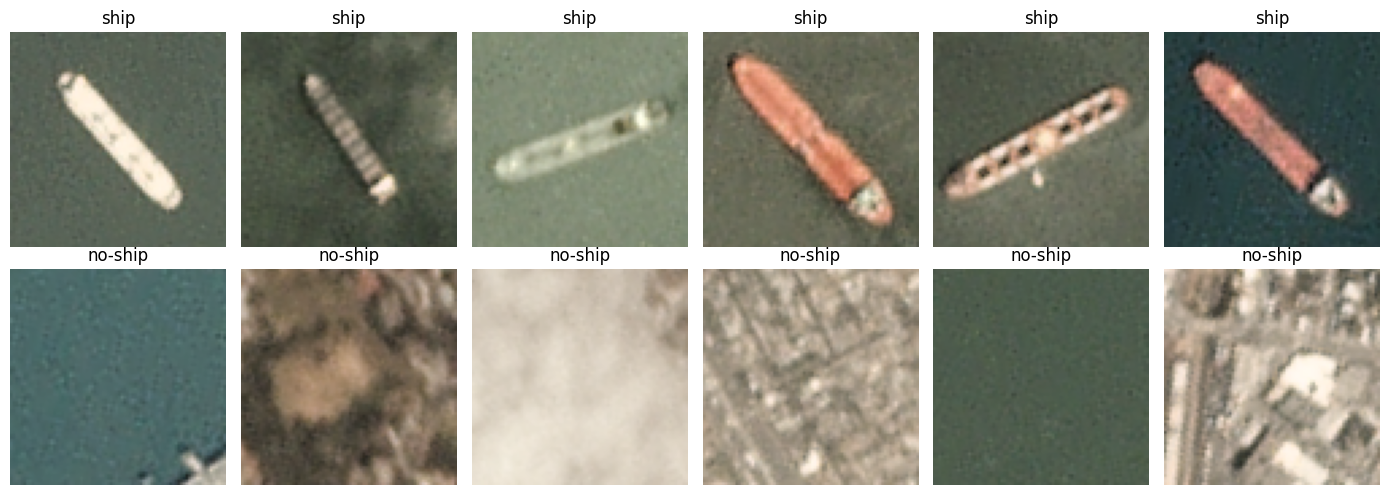

In [5]:
# Aperçu visuel de quelques vignettes
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
ship_samples = [it for it in shipsnet_items if it[1] == 1][:6]
noship_samples = [it for it in shipsnet_items if it[1] == 0][:6]

def _load_img(item):
    src, lbl = item
    if isinstance(src, np.ndarray):
        return src
    return cv2.cvtColor(cv2.imread(src), cv2.COLOR_BGR2RGB)

for ax, item in zip(axes[0], ship_samples):
    ax.imshow(_load_img(item))
    ax.set_title("ship")
    ax.axis("off")
for ax, item in zip(axes[1], noship_samples):
    ax.imshow(_load_img(item))
    ax.set_title("no-ship")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Configuration

In [6]:
CONFIG = {
    "img_size": 96,       # multiple de 8 recommandé (2 downsamplings dans le stem)
    "batch_size": 32,
    "num_epochs": 20,
    "lr": 1e-3,
    "val_split": 0.15,
    "num_workers": 2,
    "num_classes": 2,     # 0 = pas de navire, 1 = navire
    "base_channels": 18,  # largeur de la branche haute résolution (style HRNet-W18)
    "output_dir": "/kaggle/working",
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["output_dir"], "checkpoints"), exist_ok=True)
CONFIG


{'img_size': 96,
 'batch_size': 32,
 'num_epochs': 20,
 'lr': 0.001,
 'val_split': 0.15,
 'num_workers': 2,
 'num_classes': 2,
 'base_channels': 18,
 'output_dir': '/kaggle/working'}

## 5. Dataset PyTorch (image, pseudo-masque uniforme)

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ShipsnetSegDataset(Dataset):
    """Construit des paires (image, masque) où le masque est uniformément
    rempli du label (0 ou 1) sur toute la surface de l'image."""

    def __init__(self, items, img_size, augment=False):
        self.items = items
        self.img_size = img_size
        self.augment = augment
        self.normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    def __len__(self):
        return len(self.items)

    def _load_img(self, src):
        if isinstance(src, np.ndarray):
            img = src.copy()
        else:
            img = cv2.cvtColor(cv2.imread(src), cv2.COLOR_BGR2RGB)
        if img.shape[0] != self.img_size or img.shape[1] != self.img_size:
            img = cv2.resize(img, (self.img_size, self.img_size))
        return img

    def __getitem__(self, idx):
        src, label = self.items[idx]
        img = self._load_img(src)

        if self.augment:
            if random.random() < 0.5:
                img = np.ascontiguousarray(img[:, ::-1, :])
            if random.random() < 0.5:
                img = np.ascontiguousarray(img[::-1, :, :])
            k = random.choice([0, 1, 2, 3])
            if k:
                img = np.ascontiguousarray(np.rot90(img, k))

        mask = np.full((self.img_size, self.img_size), label, dtype=np.int64)

        img_t = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        img_t = self.normalize(img_t)
        mask_t = torch.from_numpy(mask)

        return img_t, mask_t


random.shuffle(shipsnet_items)
n_val = int(len(shipsnet_items) * CONFIG["val_split"])
val_items = shipsnet_items[:n_val]
train_items = shipsnet_items[n_val:]
print(f"Train : {len(train_items)} | Val : {len(val_items)}")

train_dataset = ShipsnetSegDataset(train_items, CONFIG["img_size"], augment=True)
val_dataset = ShipsnetSegDataset(val_items, CONFIG["img_size"], augment=False)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)


Train : 3400 | Val : 600


## 6. Architecture HRNet (from scratch, version compacte)

Principe HRNet : après un stem qui réduit x4 la résolution, le réseau maintient **plusieurs branches en parallèle** (haute / moyenne / basse résolution) et les fusionne à répétition (chaque branche reçoit une contribution up/down-samplée de toutes les autres). Contrairement à un U-Net, la branche haute résolution n'est **jamais perdue** — elle est enrichie en continu par les branches basse résolution, ce qui préserve les détails fins tout au long du réseau.

Ici : 2 stages, 3 branches (résolutions /4, /8, /16 du stem), 2 blocs résiduels par branche et par stage, fusion multi-échelle après chaque stage. Tête finale : concaténation des 3 branches (up-samplées à la résolution du stem) + `1x1 Conv`, puis up-sampling final à la résolution d'entrée.

In [8]:
class BasicResBlock(nn.Module):
    """Bloc résiduel standard (Conv-BN-ReLU x2 + skip connection)"""

    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class StageBranches(nn.Module):
    """Applique N blocs résiduels indépendamment sur chaque branche (résolution)."""

    def __init__(self, channels_list, num_blocks=2):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(*[BasicResBlock(c) for _ in range(num_blocks)])
            for c in channels_list
        ])

    def forward(self, xs):
        return [branch(x) for branch, x in zip(self.branches, xs)]


class FuseLayer(nn.Module):
    """Fusion multi-résolution : chaque branche de sortie reçoit la somme des
    contributions de toutes les branches d'entrée (up/down-samplées + 1x1 conv)."""

    def __init__(self, channels_list):
        super().__init__()
        n = len(channels_list)
        self.n = n
        self.ops = nn.ModuleList()
        for i in range(n):  # branche de sortie i
            row = nn.ModuleList()
            for j in range(n):  # branche d'entrée j
                if j == i:
                    row.append(nn.Identity())
                elif j < i:
                    # branche j plus haute résolution -> downsample vers résolution i,
                    # en passant par les largeurs de canaux intermédiaires (comme HRNet officiel)
                    steps = []
                    in_c = channels_list[j]
                    for k in range(j, i):
                        out_c = channels_list[k + 1]
                        steps.append(nn.Conv2d(in_c, out_c, 3, stride=2, padding=1, bias=False))
                        steps.append(nn.BatchNorm2d(out_c))
                        if k < i - 1:
                            steps.append(nn.ReLU(inplace=True))
                        in_c = out_c
                    row.append(nn.Sequential(*steps))
                else:
                    # branche j plus basse résolution -> upsample vers résolution i
                    row.append(nn.Sequential(
                        nn.Conv2d(channels_list[j], channels_list[i], 1, bias=False),
                        nn.BatchNorm2d(channels_list[i]),
                        nn.Upsample(scale_factor=2 ** (j - i), mode="bilinear", align_corners=False),
                    ))
            self.ops.append(row)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, xs):
        outs = []
        for i in range(self.n):
            acc = None
            for j in range(self.n):
                contrib = self.ops[i][j](xs[j])
                acc = contrib if acc is None else acc + contrib
            outs.append(self.relu(acc))
        return outs


class HRNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2, base_channels=18):
        super().__init__()
        c = base_channels

        # Stem : réduit la résolution d'entrée x4
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, c, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c), nn.ReLU(inplace=True),
            nn.Conv2d(c, c, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c), nn.ReLU(inplace=True),
        )

        # Stage 1 : une seule branche haute résolution
        self.stage1 = StageBranches([c], num_blocks=2)

        # Transition vers 2 branches (ajoute une branche basse résolution /2)
        self.transition1 = nn.ModuleList([
            nn.Identity(),
            nn.Sequential(
                nn.Conv2d(c, c * 2, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(c * 2), nn.ReLU(inplace=True),
            ),
        ])
        self.stage2_branches = StageBranches([c, c * 2], num_blocks=2)
        self.fuse2 = FuseLayer([c, c * 2])

        # Transition vers 3 branches (ajoute une branche basse résolution /2 supplémentaire)
        self.transition2 = nn.ModuleList([
            nn.Identity(),
            nn.Identity(),
            nn.Sequential(
                nn.Conv2d(c * 2, c * 4, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(c * 4), nn.ReLU(inplace=True),
            ),
        ])
        self.stage3_branches = StageBranches([c, c * 2, c * 4], num_blocks=2)
        self.fuse3 = FuseLayer([c, c * 2, c * 4])

        # Tête de segmentation : concatène les 3 branches up-samplées à la résolution du stem
        total_c = c + c * 2 + c * 4
        self.head = nn.Sequential(
            nn.Conv2d(total_c, c, kernel_size=1, bias=False),
            nn.BatchNorm2d(c), nn.ReLU(inplace=True),
            nn.Conv2d(c, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        x = self.stem(x)                       # résolution /4
        x1 = self.stage1([x])[0]

        x_high = self.transition1[0](x1)
        x_low = self.transition1[1](x1)
        x_high, x_low = self.stage2_branches([x_high, x_low])
        x_high, x_low = self.fuse2([x_high, x_low])

        x_hh = self.transition2[0](x_high)
        x_ll = self.transition2[1](x_low)
        x_lll = self.transition2[2](x_low)
        x_hh, x_ll, x_lll = self.stage3_branches([x_hh, x_ll, x_lll])
        x_hh, x_ll, x_lll = self.fuse3([x_hh, x_ll, x_lll])

        target_size = x_hh.shape[-2:]
        x_ll_up = F.interpolate(x_ll, size=target_size, mode="bilinear", align_corners=False)
        x_lll_up = F.interpolate(x_lll, size=target_size, mode="bilinear", align_corners=False)
        fused = torch.cat([x_hh, x_ll_up, x_lll_up], dim=1)

        out = self.head(fused)
        out = F.interpolate(out, size=input_size, mode="bilinear", align_corners=False)
        return out


model = HRNet(in_channels=3, num_classes=CONFIG["num_classes"],
              base_channels=CONFIG["base_channels"]).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {n_params:,}")

# Vérification rapide de la forme de sortie
with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG["img_size"], CONFIG["img_size"]).to(device)
    out = model(dummy)
    print("Shape de sortie :", out.shape)  # attendu : (2, num_classes, img_size, img_size)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["num_epochs"])


Nombre de paramètres : 421,724
Shape de sortie : torch.Size([2, 2, 96, 96])


## 7. Boucle d'entraînement

In [9]:
def pixel_accuracy(preds, masks):
    return (preds == masks).float().mean().item()


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, running_acc, n_batches = 0.0, 0.0, 0
    torch.set_grad_enabled(is_train)
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        if is_train:
            loss.backward()
            optimizer.step()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item()
        running_acc += pixel_accuracy(preds, masks)
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
ckpt_path = os.path.join(CONFIG["output_dir"], "checkpoints", "hrnet_ships_best.pth")

start_time = time.time()
for epoch in range(CONFIG["num_epochs"]):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']} "
          f"- train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, ckpt_path)
        print(f"  -> Nouveau meilleur modèle sauvegardé (val_acc={val_acc:.4f})")

elapsed = time.time() - start_time
print(f"\nEntraînement terminé en {elapsed/60:.1f} min. Meilleure val_acc : {best_val_acc:.4f}")

model.load_state_dict(best_model_wts)


Epoch 1/20 - train_loss: 0.3917 train_acc: 0.8410 - val_loss: 0.2797 val_acc: 0.8899
  -> Nouveau meilleur modèle sauvegardé (val_acc=0.8899)
Epoch 2/20 - train_loss: 0.1978 train_acc: 0.9346 - val_loss: 0.2726 val_acc: 0.8931
  -> Nouveau meilleur modèle sauvegardé (val_acc=0.8931)
Epoch 3/20 - train_loss: 0.1464 train_acc: 0.9494 - val_loss: 0.0948 val_acc: 0.9700
  -> Nouveau meilleur modèle sauvegardé (val_acc=0.9700)
Epoch 4/20 - train_loss: 0.1273 train_acc: 0.9557 - val_loss: 0.1638 val_acc: 0.9428
Epoch 5/20 - train_loss: 0.0993 train_acc: 0.9666 - val_loss: 0.0934 val_acc: 0.9679
Epoch 6/20 - train_loss: 0.0830 train_acc: 0.9725 - val_loss: 0.0670 val_acc: 0.9755
  -> Nouveau meilleur modèle sauvegardé (val_acc=0.9755)
Epoch 7/20 - train_loss: 0.0730 train_acc: 0.9761 - val_loss: 0.0728 val_acc: 0.9745
Epoch 8/20 - train_loss: 0.0697 train_acc: 0.9776 - val_loss: 0.0804 val_acc: 0.9700
Epoch 9/20 - train_loss: 0.0501 train_acc: 0.9828 - val_loss: 0.0384 val_acc: 0.9875
  -> No

<All keys matched successfully>

## 8. Courbes d'entraînement

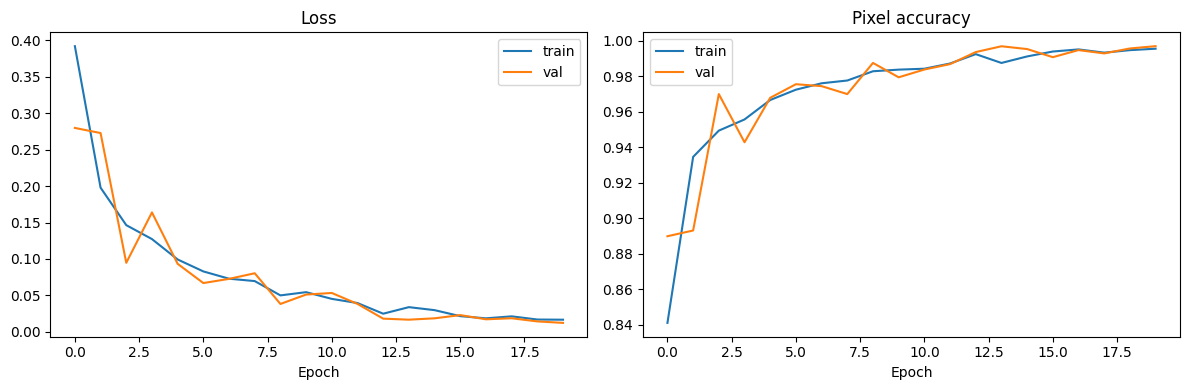

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Pixel accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
curves_path = os.path.join(CONFIG["output_dir"], "training_curves.png")
plt.savefig(curves_path, dpi=150)
plt.show()


## 9. Inférence en sliding-window sur les grandes scènes (`scenes/`)

On découpe chaque grande image en tuiles de la taille utilisée à l'entraînement, on classe chaque tuile avec le modèle, et on reconstruit une carte de probabilité de présence de navire sur toute la scène (carte de segmentation dense).

8 scène(s) trouvée(s) pour la démonstration.


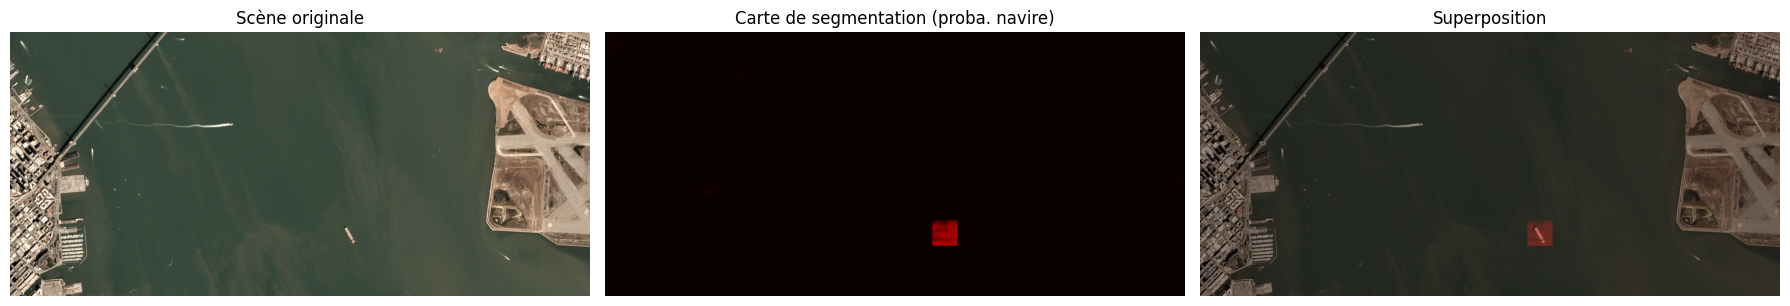

In [19]:
def sliding_window_segmentation(model, scene_path, tile_size, stride):
    scene = cv2.cvtColor(cv2.imread(scene_path), cv2.COLOR_BGR2RGB)
    H, W = scene.shape[:2]

    prob_map = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    model.eval()

    with torch.no_grad():
        for y in range(0, max(H - tile_size, 0) + 1, stride):
            for x in range(0, max(W - tile_size, 0) + 1, stride):
                tile = scene[y:y + tile_size, x:x + tile_size]
                if tile.shape[0] != tile_size or tile.shape[1] != tile_size:
                    continue
                tile_t = torch.from_numpy(tile.transpose(2, 0, 1)).float() / 255.0
                tile_t = normalize(tile_t).unsqueeze(0).to(device)

                out = model(tile_t)
                prob = F.softmax(out, dim=1)[0, 1]  # proba classe "ship"
                prob_map[y:y + tile_size, x:x + tile_size] += prob.cpu().numpy()
                count_map[y:y + tile_size, x:x + tile_size] += 1.0

    count_map[count_map == 0] = 1.0
    prob_map /= count_map
    return scene, prob_map


scene_paths = glob.glob(os.path.join(SCENES_DIR, "*"))
scene_paths = [p for p in scene_paths if Path(p).suffix.lower() in [".png", ".jpg", ".jpeg"]]
print(f"{len(scene_paths)} scène(s) trouvée(s) pour la démonstration.")

if scene_paths:
    demo_scene_path = scene_paths[1]
    scene_img, prob_map = sliding_window_segmentation(
        model, demo_scene_path, tile_size=CONFIG["img_size"], stride=CONFIG["img_size"] // 2
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(scene_img)
    axes[0].set_title("Scène originale")
    axes[0].axis("off")

    axes[1].imshow(prob_map, cmap="hot", vmin=0, vmax=1)
    axes[1].set_title("Carte de segmentation (proba. navire)")
    axes[1].axis("off")

    axes[2].imshow(scene_img)
    axes[2].imshow(prob_map, cmap="hot", alpha=0.45, vmin=0, vmax=1)
    axes[2].set_title("Superposition")
    axes[2].axis("off")

    plt.tight_layout()
    seg_demo_path = os.path.join(CONFIG["output_dir"], "scene_segmentation_demo.png")
    plt.savefig(seg_demo_path, dpi=150)
    plt.show()
else:
    print("Aucune scène disponible dans scenes/ pour la démonstration.")
    seg_demo_path = None


## 10. Récapitulatif des fichiers sauvegardés

In [12]:
print("Fichiers sauvegardés dans", CONFIG["output_dir"], ":")
for p in [ckpt_path, curves_path, seg_demo_path]:
    if p:
        print(" -", p)


Fichiers sauvegardés dans /kaggle/working :
 - /kaggle/working/checkpoints/hrnet_ships_best.pth
 - /kaggle/working/training_curves.png
 - /kaggle/working/scene_segmentation_demo.png
